**Student1:** Hammani Abdeslem

**Student2:** Fellah Mahdi

# Advanced Machine Learning - Week 2 Lab
## Reinforcement Learning Part 1: MDPs, Value Iteration & Q-Learning

**Learning Objectives:**
1. Understand Markov Decision Processes (MDPs) formalism
2. Implement Value Iteration algorithm
3. Implement Q-Learning from scratch
4. Apply Q-Learning to GridWorld and Gymnasium environments
5. Analyze exploration vs exploitation trade-offs
6. Visualize learning dynamics and policies

**Duration:** 2 hours

**Structure:**
- Part 1: MDP Basics & GridWorld Environment
- Part 2: Value Iteration (Dynamic Programming)
- Part 3: Q-Learning Implementation
- Part 4: Gymnasium FrozenLake Environment
- Part 5: Analysis & Visualization
- Part 6: Advanced Extensions

---

## Theoretical Recap

### What is Reinforcement Learning?

**Classical ML:** Learn from labeled examples $(x, y)$

**Reinforcement Learning:** Learn from interaction with environment
- Agent observes **state** $s_t$
- Takes **action** $a_t$
- Receives **reward** $r_t$
- Transitions to new **state** $s_{t+1}$

**Goal:** Maximize cumulative reward (return)

### Markov Decision Process (MDP)

Formally, an MDP is defined by:
- $\mathcal{S}$: State space
- $\mathcal{A}$: Action space
- $P(s'|s,a)$: Transition probability
- $R(s,a,s')$: Reward function
- $\gamma \in [0,1)$: Discount factor

**Markov Property:** Future depends only on current state, not history

$$P(s_{t+1}|s_t, a_t, s_{t-1}, \ldots) = P(s_{t+1}|s_t, a_t)$$

### Key Concepts

**Policy** $\pi(a|s)$: Strategy for choosing actions
- Deterministic: $a = \pi(s)$
- Stochastic: $a \sim \pi(\cdot|s)$

**Value Function** $V^\pi(s)$: Expected return from state $s$ following policy $\pi$
$$V^\pi(s) = \mathbb{E}_\pi\left[\sum_{t=0}^\infty \gamma^t r_t \mid s_0 = s\right]$$

**Q-Function** $Q^\pi(s,a)$: Expected return from state $s$, taking action $a$, then following $\pi$
$$Q^\pi(s,a) = \mathbb{E}_\pi\left[\sum_{t=0}^\infty \gamma^t r_t \mid s_0 = s, a_0 = a\right]$$

**Bellman Equation:** Recursive relationship
$$V(s) = \max_a \left[R(s,a) + \gamma \sum_{s'} P(s'|s,a) V(s')\right]$$

---

## Part 1: Setup & GridWorld Environment

In [2]:
# Install required packages (uncomment if needed)
# !pip install -q gymnasium pygame numpy matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# For Gymnasium environments
import gymnasium as gym

# Set random seeds
SEED = 42
np.random.seed(SEED)

print("All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Gymnasium version: {gym.__version__}")

All imports successful!
NumPy version: 2.4.2
Gymnasium version: 1.2.3


### 1.1 Simple GridWorld Environment

Let's start with a simple 4×4 GridWorld:

```
S  .  .  .
.  #  .  .
.  .  .  #
.  .  .  G
```

- **S**: Start position (state 0)
- **G**: Goal position (state 15)
- **#**: Obstacles (states 5, 11)
- **.**: Empty cells

**Actions:** UP (0), RIGHT (1), DOWN (2), LEFT (3)

**Rewards:**
- Goal: +1.0
- Obstacles: -1.0
- Step: -0.01 (encourage shorter paths)

**Dynamics:** Deterministic movement (100% success rate)

In [2]:
class SimpleGridWorld:
    """
    Simple 4x4 GridWorld MDP for educational purposes.
    
    State representation: Integer from 0 to 15 (row-major order)
    Actions: 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT
    """
    
    def __init__(self, size=4):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        
        # Define special states
        self.start_state = 0
        self.goal_state = 15
        self.obstacles = [5, 11]  # States that are obstacles
        
        # Current state
        self.state = self.start_state
        
        # Action names for visualization
        self.action_names = ['UP', 'RIGHT', 'DOWN', 'LEFT']
        
        # Movement deltas: [row_delta, col_delta]
        self.action_deltas = [
            (-1, 0),  # UP
            (0, 1),   # RIGHT
            (1, 0),   # DOWN
            (0, -1)   # LEFT
        ]
    
    def state_to_position(self, state):
        """Convert state index to (row, col) position"""
        return (state // self.size, state % self.size)
    
    def position_to_state(self, row, col):
        """Convert (row, col) position to state index"""
        return row * self.size + col
    
    def is_valid_position(self, row, col):
        """Check if position is within grid bounds"""
        return 0 <= row < self.size and 0 <= col < self.size
    
    def step(self, action):
        """
        Execute action and return (next_state, reward, done)
        
        Args:
            action: int in [0, 1, 2, 3]
        
        Returns:
            next_state: int
            reward: float
            done: bool
        """
        # Get current position
        row, col = self.state_to_position(self.state)
        
        # Apply action
        delta_row, delta_col = self.action_deltas[action]
        new_row = row + delta_row
        new_col = col + delta_col
        
        # Check if new position is valid
        if self.is_valid_position(new_row, new_col):
            next_state = self.position_to_state(new_row, new_col)
        else:
            # Hit wall, stay in place
            next_state = self.state
        
        # Determine reward and done flag
        if next_state == self.goal_state:
            reward = 1.0
            done = True
        elif next_state in self.obstacles:
            reward = -1.0
            done = True
        else:
            reward = -0.01  # Small negative reward to encourage shorter paths
            done = False
        
        # Update state
        self.state = next_state
        
        return next_state, reward, done
    
    def reset(self):
        """Reset environment to start state"""
        self.state = self.start_state
        return self.state
    
    def render(self):
        """Print current grid state"""
        grid = []
        for state in range(self.n_states):
            if state == self.state:
                symbol = 'A'  # Agent
            elif state == self.goal_state:
                symbol = 'G'  # Goal
            elif state in self.obstacles:
                symbol = '#'  # Obstacle
            elif state == self.start_state:
                symbol = 'S'  # Start
            else:
                symbol = '.'
            grid.append(symbol)
        
        # Print grid
        for i in range(self.size):
            row = grid[i*self.size:(i+1)*self.size]
            print(' '.join(row))
        print()

# Create environment and test
env = SimpleGridWorld()
print("Initial GridWorld:")
env.render()

# Test movement
print("Taking action RIGHT:")
next_state, reward, done = env.step(1)
print(f"Next state: {next_state}, Reward: {reward:.3f}, Done: {done}")
env.render()

print("GridWorld environment created!")

Initial GridWorld:
A . . .
. # . .
. . . #
. . . G

Taking action RIGHT:
Next state: 1, Reward: -0.010, Done: False
S A . .
. # . .
. . . #
. . . G

GridWorld environment created!


### Exercise 1: Understanding the Environment

**Questions:**
1. How many total states does this GridWorld have?
2. What is the state number of the cell at position (row=2, col=3)?
3. If the agent is at state 6, what happens if it takes action DOWN?
4. Why do we give a small negative reward (-0.01) for each step?

**Task:** Complete the code below to answer these questions.

In [5]:
# Exercise 1 - Your answers here

# Q1: Total states
total_states = env.n_states
print(f"Q1: Total states = {total_states}")

# Q2: State at position (2, 3)
state_2_3 = env.position_to_state(2, 3)
print(f"Q2: State at (2,3) = {state_2_3}")

# Q3: Simulate action from state 6
env.reset()
env.state = 6
print(f"\nQ3: Agent at state 6")
env.render()
next_s, r, d = env.step(2)  # DOWN
print(f"After DOWN: state={next_s}, reward={r:.3f}, done={d}")
env.render()

# Q4: Discussion
print("Q4: Small negative rewards encourage the agent to find SHORTER paths.")
print("    Without this, all paths to goal would have same value.")

Q1: Total states = 16
Q2: State at (2,3) = 11

Q3: Agent at state 6
S . . .
. # A .
. . . #
. . . G

After DOWN: state=10, reward=-0.010, done=False
S . . .
. # . .
. . A #
. . . G

Q4: Small negative rewards encourage the agent to find SHORTER paths.
    Without this, all paths to goal would have same value.


---
## Part 2: Value Iteration (Dynamic Programming)

### Theory: Value Iteration Algorithm

Value Iteration is a **dynamic programming** algorithm that computes the optimal value function.

**Algorithm:**
1. Initialize $V(s) = 0$ for all states $s$
2. Repeat until convergence:
   - For each state $s$:
     $$V_{k+1}(s) = \max_a \left[R(s,a) + \gamma \sum_{s'} P(s'|s,a) V_k(s')\right]$$
3. Extract policy: $\pi^*(s) = \arg\max_a Q(s,a)$

**Key insight:** Optimal value function satisfies Bellman optimality equation.

**Example:**
Consider state 10 in our GridWorld:
- Position: (2, 2)
- Possible actions: UP, RIGHT, DOWN, LEFT
- For action RIGHT: next state = 11 (obstacle, R=-1)
- For action DOWN: next state = 14, then can reach goal

Value Iteration will learn that DOWN from state 10 is better than RIGHT.

In [4]:
def value_iteration(env, gamma=0.9, theta=1e-6, max_iterations=1000):
    """
    Value Iteration algorithm for solving MDP.
    
    Args:
        env: GridWorld environment
        gamma: Discount factor
        theta: Convergence threshold
        max_iterations: Maximum number of iterations
    
    Returns:
        V: Optimal value function (numpy array)
        policy: Optimal policy (numpy array of actions)
        history: List of value functions at each iteration
    """
    # Initialize value function
    V = np.zeros(env.n_states)
    history = [V.copy()]
    
    for iteration in range(max_iterations):
        delta = 0  # Track maximum change
        V_new = np.zeros(env.n_states)
        
        # Update each state
        for state in range(env.n_states):
            # Skip terminal states
            if state == env.goal_state or state in env.obstacles:
                V_new[state] = 0
                continue
            
            # Compute Q-values for all actions
            q_values = []
            for action in range(env.n_actions):
                # Simulate action (deterministic environment)
                env.state = state
                next_state, reward, done = env.step(action)
                
                # Bellman update
                q_value = reward + gamma * V[next_state]
                q_values.append(q_value)
            
            # Take maximum over actions
            V_new[state] = max(q_values)
            
            # Track change
            delta = max(delta, abs(V_new[state] - V[state]))
        
        # Update value function
        V = V_new.copy()
        history.append(V.copy())
        
        # Check convergence
        if delta < theta:
            print(f"Converged after {iteration + 1} iterations")
            break
    
    # Extract optimal policy
    policy = np.zeros(env.n_states, dtype=int)
    for state in range(env.n_states):
        if state == env.goal_state or state in env.obstacles:
            policy[state] = -1  # No action for terminal states
            continue
        
        # Find best action
        q_values = []
        for action in range(env.n_actions):
            env.state = state
            next_state, reward, done = env.step(action)
            q_value = reward + gamma * V[next_state]
            q_values.append(q_value)
        
        policy[state] = np.argmax(q_values)
    
    return V, policy, history

# Run Value Iteration
print("Running Value Iteration...")
V_opt, policy_opt, vi_history = value_iteration(env, gamma=0.9)

print("\nOptimal Value Function:")
print(V_opt.reshape(4, 4))

print("\nOptimal Policy:")
policy_symbols = []
for state in range(env.n_states):
    if state == env.goal_state:
        policy_symbols.append('G')
    elif state in env.obstacles:
        policy_symbols.append('#')
    else:
        action = policy_opt[state]
        symbols = ['↑', '→', '↓', '←']
        policy_symbols.append(symbols[action])

for i in range(4):
    row = policy_symbols[i*4:(i+1)*4]
    print(' '.join(row))

Running Value Iteration...
Converged after 7 iterations

Optimal Value Function:
[[0.549539 0.62171  0.7019   0.62171 ]
 [0.62171  0.       0.791    0.7019  ]
 [0.7019   0.791    0.89     0.      ]
 [0.791    0.89     1.       0.      ]]

Optimal Policy:
→ → ↓ ↓
↓ # ↓ ←
→ → ↓ #
→ → → G


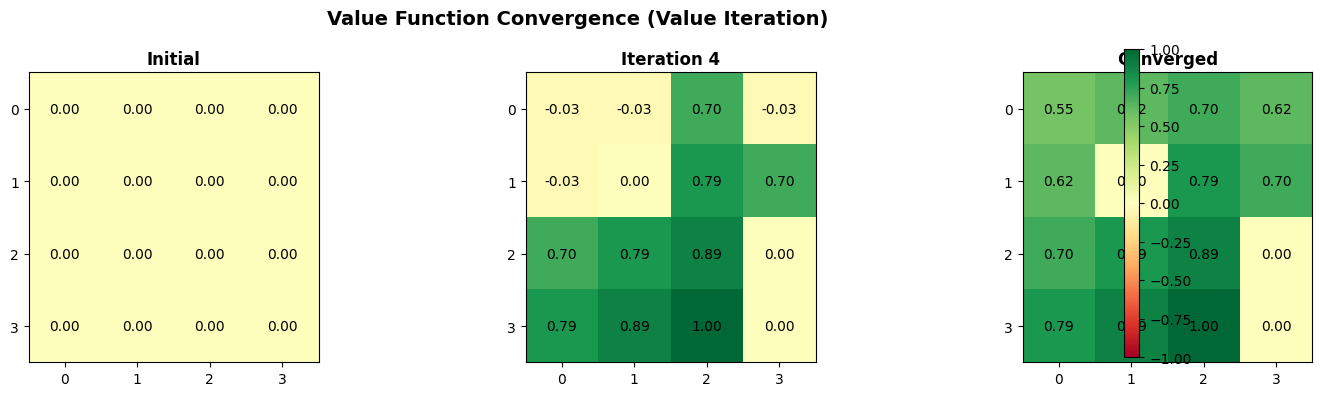

In [5]:
# Visualize value function convergence
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

iterations_to_plot = [0, len(vi_history)//2, len(vi_history)-1]
titles = ['Initial', f'Iteration {iterations_to_plot[1]}', 'Converged']

for idx, (iter_num, title) in enumerate(zip(iterations_to_plot, titles)):
    ax = axes[idx]
    V_grid = vi_history[iter_num].reshape(4, 4)
    im = ax.imshow(V_grid, cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.grid(False)
    
    # Annotate values
    for i in range(4):
        for j in range(4):
            text = ax.text(j, i, f'{V_grid[i, j]:.2f}',
                            ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
plt.suptitle('Value Function Convergence (Value Iteration)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Exercise 2: Understanding Value Iteration

**Questions:**
1. Why is the value of the goal state 0?
2. Which state has the highest value? Why?
3. What happens if we increase gamma from 0.9 to 0.99?
4. How does the policy change if we remove the step penalty (-0.01)?

**Task:** Experiment with different parameters below.

In [7]:
# Exercise 2 - Experiment with parameters

# Q1: Goal state value is 0 because it's terminal (no future rewards)
print("Q1: Goal state is terminal, V(goal) = 0 by definition.")

# Q2: Find highest value state
max_state = np.argmax(V_opt)
print(f"\nQ2: Highest value state = {max_state} (position {env.state_to_position(max_state)})")
print(f"    Value = {V_opt[max_state]:.3f}")
print(f"    This state is closest to goal with fewest obstacles in the way.")

# Q3: Test with higher gamma
print("\nQ3: Testing with gamma = 0.99...")
V_high_gamma, _, _ = value_iteration(env, gamma=0.99, theta=1e-6)
print("Optimal values with gamma=0.99:")
print(V_high_gamma.reshape(4, 4))
print("Higher gamma = agent cares more about future rewards.")
print("Values become larger (less discounting).")

Q1: Goal state is terminal, V(goal) = 0 by definition.

Q2: Highest value state = 14 (position (np.int64(3), np.int64(2)))
    Value = 1.000
    This state is closest to goal with fewest obstacles in the way.

Q3: Testing with gamma = 0.99...
Converged after 7 iterations
Optimal values with gamma=0.99:
[[0.9019801  0.92119202 0.940598   0.92119202]
 [0.92119202 0.         0.9602     0.940598  ]
 [0.940598   0.9602     0.98       0.        ]
 [0.9602     0.98       1.         0.        ]]
Higher gamma = agent cares more about future rewards.
Values become larger (less discounting).


In [6]:
import copy
import numpy as np

print("\nQ4: Testing with NO step penalty (reward = 0 per step)...")

# 1. Create a deep copy of the environment so we don't ruin the original
env_no_penalty = copy.deepcopy(env)

# 2. Override the step method to replace -0.01 rewards with 0.0
_original_step = env_no_penalty.step

def _step_no_penalty(action):
    next_state, reward, done = _original_step(action)
    # Change the step penalty to 0.0, but keep goal (+1) or obstacles (-1)
    if reward == -0.01:
        reward = 0.0
    return next_state, reward, done

env_no_penalty.step = _step_no_penalty

# 3. Run Value Iteration on the modified environment
V_no_penalty, pi_no_penalty, _ = value_iteration(env_no_penalty, gamma=0.99, theta=1e-6)

# 4. Display the results
print("\nOptimal values without step penalty:")
print(np.round(V_no_penalty.reshape(4, 4), 3))

print("\nOptimal policy without step penalty:")
# We use a dictionary to map action indices to arrows for visualization
action_symbols = {0: '↑', 1: '→', 2: '↓', 3: '←'}

for i in range(4):
    row_syms = []
    for j in range(4):
        s = i * 4 + j
        # Assuming your environment has attributes 'goal_state' and 'obstacles'
        if hasattr(env, 'goal_state') and s == env.goal_state:
            row_syms.append('G')
        elif hasattr(env, 'obstacles') and s in env.obstacles:
            row_syms.append('#')
        else:
            row_syms.append(action_symbols[pi_no_penalty[s]])
    print(' '.join(row_syms))

print("\nObservation:")
print("- Without a step penalty (and with high gamma), the agent loses its sense of 'urgency'.")
print("- It may take longer paths because wandering around no longer hurts its cumulative score linearly.")
print("- The values of states further from the goal are much higher now compared to before.")


Q4: Testing with NO step penalty (reward = 0 per step)...
Converged after 7 iterations

Optimal values without step penalty:
[[0.951 0.961 0.97  0.961]
 [0.961 0.    0.98  0.97 ]
 [0.97  0.98  0.99  0.   ]
 [0.98  0.99  1.    0.   ]]

Optimal policy without step penalty:
→ → ↓ ↓
↓ # ↓ ←
→ → ↓ #
→ → → G

Observation:
- Without a step penalty (and with high gamma), the agent loses its sense of 'urgency'.
- It may take longer paths because wandering around no longer hurts its cumulative score linearly.
- The values of states further from the goal are much higher now compared to before.


---
## Part 3: Q-Learning Implementation

### Theory: Q-Learning Algorithm

Q-Learning is a **model-free** algorithm that learns Q-values directly from experience.

**Key difference from Value Iteration:**
- Value Iteration: Needs full model (transition probabilities)
- Q-Learning: Learns from samples, no model needed

**Algorithm:**
1. Initialize Q(s,a) = 0 for all state-action pairs
2. For each episode:
   - Start from initial state
   - For each step:
     - Choose action using ε-greedy policy
     - Execute action, observe reward and next state
     - Update Q-value:
       $$Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]$$

**Temporal Difference (TD) Error:**
$$\delta = r + \gamma \max_{a'} Q(s',a') - Q(s,a)$$

This is the difference between predicted Q-value and actual observed return.

**ε-Greedy Exploration:**
- With probability ε: choose random action (explore)
- With probability 1-ε: choose best action (exploit)

**Example:**
Suppose we're at state 10, take action DOWN, reach state 14 with reward -0.01.

Current: Q(10, DOWN) = 0.5

Best action from state 14: Q(14, RIGHT) = 0.8

TD error: δ = -0.01 + 0.9 × 0.8 - 0.5 = 0.21

Update: Q(10, DOWN) = 0.5 + 0.1 × 0.21 = 0.521

In [8]:
class QLearningAgent:
    """
    Q-Learning agent implementation.
    """
    
    def __init__(self, n_states, n_actions, learning_rate=0.1, 
                    gamma=0.9, epsilon=1.0, epsilon_decay=0.995, 
                    epsilon_min=0.01):
        """
        Initialize Q-Learning agent.
        
        Args:
            n_states: Number of states
            n_actions: Number of actions
            learning_rate: α in Q-learning update
            gamma: Discount factor
            epsilon: Initial exploration rate
            epsilon_decay: Rate of epsilon decay per episode
            epsilon_min: Minimum epsilon value
        """
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        
        # Initialize Q-table
        self.Q = np.zeros((n_states, n_actions))
        
        # Statistics
        self.episode_rewards = []
        self.episode_lengths = []
        self.td_errors = []
    
    def select_action(self, state, mode='train'):
        """
        Select action using ε-greedy policy.
        
        Args:
            state: Current state
            mode: 'train' (use epsilon) or 'test' (greedy)
        
        Returns:
            action: Selected action
        """
        if mode == 'train' and np.random.random() < self.epsilon:
            # Explore: random action
            return np.random.randint(self.n_actions)
        else:
            # Exploit: best action
            return np.argmax(self.Q[state])
    
    def update(self, state, action, reward, next_state, done):
        """
        Update Q-value using Q-learning rule.
        
        Args:
            state: Current state
            action: Action taken
            reward: Reward received
            next_state: Next state
            done: Whether episode ended
        """
        # Current Q-value
        current_q = self.Q[state, action]
        
        # TD target
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.Q[next_state])
        
        # TD error
        td_error = target - current_q
        self.td_errors.append(abs(td_error))
        
        # Q-learning update
        self.Q[state, action] = current_q + self.alpha * td_error
    
    def decay_epsilon(self):
        """Decay exploration rate"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
    
    def get_policy(self):
        """Extract greedy policy from Q-table"""
        return np.argmax(self.Q, axis=1)

print("Q-Learning agent class defined")

Q-Learning agent class defined


In [9]:
def train_q_learning(env, agent, n_episodes=500, max_steps=100, verbose=True):
    """
    Train Q-Learning agent.
    
    Args:
        env: Environment
        agent: QLearningAgent
        n_episodes: Number of training episodes
        max_steps: Maximum steps per episode
        verbose: Print progress
    
    Returns:
        agent: Trained agent
    """
    for episode in range(n_episodes):
        state = env.reset()
        episode_reward = 0
        
        for step in range(max_steps):
            # Select action
            action = agent.select_action(state, mode='train')
            
            # Execute action
            next_state, reward, done = env.step(action)
            
            # Update Q-value
            agent.update(state, action, reward, next_state, done)
            
            # Update statistics
            episode_reward += reward
            state = next_state
            
            if done:
                break
        
        # Store episode statistics
        agent.episode_rewards.append(episode_reward)
        agent.episode_lengths.append(step + 1)
        
        # Decay epsilon
        agent.decay_epsilon()
        
        # Print progress
        if verbose and (episode + 1) % 100 == 0:
            avg_reward = np.mean(agent.episode_rewards[-100:])
            avg_length = np.mean(agent.episode_lengths[-100:])
            print(f"Episode {episode+1}/{n_episodes} | "
                    f"Avg Reward: {avg_reward:.3f} | "
                    f"Avg Length: {avg_length:.1f} | "
                    f"Epsilon: {agent.epsilon:.3f}")
    
    return agent

# Create and train Q-Learning agent
print("Training Q-Learning agent on GridWorld...")
print("="*70)

q_agent = QLearningAgent(
    n_states=env.n_states,
    n_actions=env.n_actions,
    learning_rate=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01
)

q_agent = train_q_learning(env, q_agent, n_episodes=500, max_steps=100)

print("\nQ-Learning training complete!")

Training Q-Learning agent on GridWorld...
Episode 100/500 | Avg Reward: -0.690 | Avg Length: 10.0 | Epsilon: 0.606
Episode 200/500 | Avg Reward: 0.203 | Avg Length: 8.7 | Epsilon: 0.367
Episode 300/500 | Avg Reward: 0.591 | Avg Length: 7.9 | Epsilon: 0.222
Episode 400/500 | Avg Reward: 0.820 | Avg Length: 7.0 | Epsilon: 0.135
Episode 500/500 | Avg Reward: 0.826 | Avg Length: 6.4 | Epsilon: 0.082

Q-Learning training complete!


In [10]:
# Visualize learned Q-values
print("\nLearned Q-Table (first 8 states):")
print("State | UP      RIGHT   DOWN    LEFT")
print("-" * 45)
for s in range(8):
    q_vals = q_agent.Q[s]
    print(f"{s:3d}   | {q_vals[0]:6.3f}  {q_vals[1]:6.3f}  {q_vals[2]:6.3f}  {q_vals[3]:6.3f}")

# Extract and display learned policy
learned_policy = q_agent.get_policy()
print("\nLearned Policy:")
policy_symbols = []
for state in range(env.n_states):
    if state == env.goal_state:
        policy_symbols.append('G')
    elif state in env.obstacles:
        policy_symbols.append('#')
    else:
        action = learned_policy[state]
        symbols = ['↑', '→', '↓', '←']
        policy_symbols.append(symbols[action])

for i in range(4):
    row = policy_symbols[i*4:(i+1)*4]
    print(' '.join(row))


Learned Q-Table (first 8 states):
State | UP      RIGHT   DOWN    LEFT
---------------------------------------------
  0   |  0.431   0.317   0.550   0.456
  1   | -0.012  -0.007  -0.942   0.450
  2   | -0.008  -0.011   0.061   0.004
  3   | -0.010  -0.010  -0.010  -0.010
  4   |  0.454  -0.997   0.622   0.460
  5   |  0.000   0.000   0.000   0.000
  6   | -0.005  -0.009   0.373  -0.570
  7   | -0.007  -0.007  -0.410  -0.002

Learned Policy:
↓ ← ↓ →
↓ # ↓ ←
→ ↓ ↓ #
→ → → G


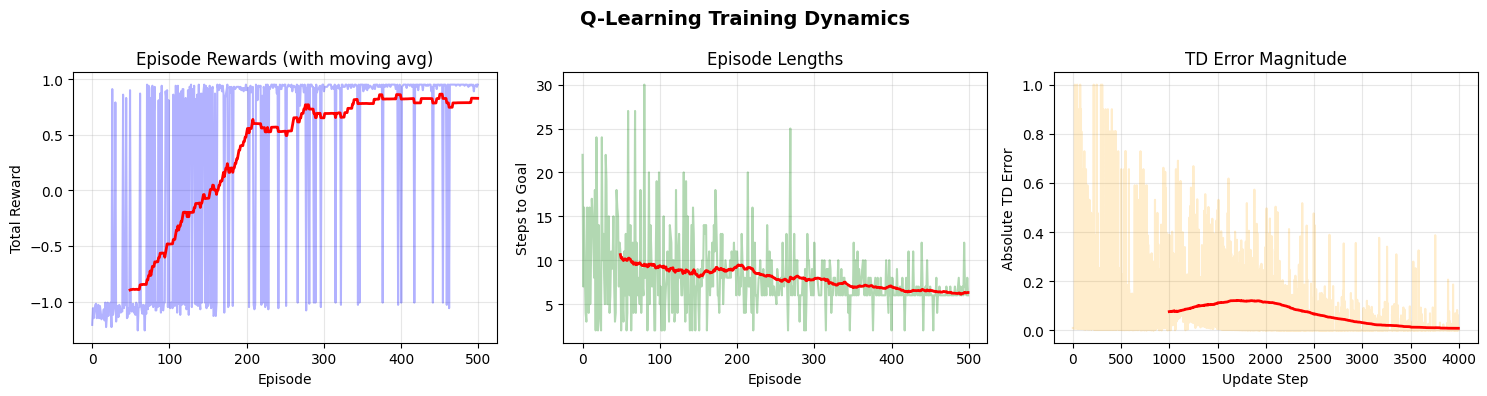

In [11]:
# Plot learning curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Episode rewards
ax = axes[0]
ax.plot(q_agent.episode_rewards, alpha=0.3, color='blue')
# Moving average
window = 50
ma = np.convolve(q_agent.episode_rewards, np.ones(window)/window, mode='valid')
ax.plot(range(window-1, len(q_agent.episode_rewards)), ma, color='red', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Episode Rewards (with moving avg)')
ax.grid(True, alpha=0.3)

# Episode lengths
ax = axes[1]
ax.plot(q_agent.episode_lengths, alpha=0.3, color='green')
ma_len = np.convolve(q_agent.episode_lengths, np.ones(window)/window, mode='valid')
ax.plot(range(window-1, len(q_agent.episode_lengths)), ma_len, color='red', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Steps to Goal')
ax.set_title('Episode Lengths')
ax.grid(True, alpha=0.3)

# TD errors
ax = axes[2]
ax.plot(q_agent.td_errors, alpha=0.2, color='orange')
window_td = 1000
if len(q_agent.td_errors) > window_td:
    ma_td = np.convolve(q_agent.td_errors, np.ones(window_td)/window_td, mode='valid')
    ax.plot(range(window_td-1, len(q_agent.td_errors)), ma_td, color='red', linewidth=2)
ax.set_xlabel('Update Step')
ax.set_ylabel('Absolute TD Error')
ax.set_title('TD Error Magnitude')
ax.grid(True, alpha=0.3)

plt.suptitle('Q-Learning Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Exercise 3: Q-Learning Analysis

**Questions:**
1. Compare the learned policy with Value Iteration's policy. Are they the same?
2. Why does episode reward increase over time?
3. Why does TD error decrease over time?
4. What happens if learning rate α is too large (e.g., α=0.9)?

**Task:** Experiment below.

In [13]:
# Exercise 3 - Analysis

# Q1: Compare policies
print("Q1: Policy Comparison")
print("\nValue Iteration Policy:")
for i in range(4):
    row_vi = []
    for j in range(4):
        s = i*4 + j
        if s == env.goal_state:
            row_vi.append('G')
        elif s in env.obstacles:
            row_vi.append('#')
        else:
            row_vi.append(['↑','→','↓','←'][policy_opt[s]])
    print(' '.join(row_vi))

print("\nQ-Learning Policy:")
for i in range(4):
    row = policy_symbols[i*4:(i+1)*4]
    print(' '.join(row))

# Check if identical
policies_match = np.array_equal(
    policy_opt[np.where((policy_opt >= 0))], 
    learned_policy[np.where((policy_opt >= 0))]
)
print(f"\nPolicies match: {policies_match}")

# Q2 & Q3: Explained by learning
print("\nQ2: Episode rewards increase as agent learns better policy (more efficient paths).")
print("Q3: TD error decreases as Q-values converge to true values (less prediction error).")

Q1: Policy Comparison

Value Iteration Policy:
→ → ↓ ↓
↓ # ↓ ←
→ → ↓ #
→ → → G

Q-Learning Policy:
↓ ← ↓ →
↓ # ↓ ←
→ ↓ ↓ #
→ → → G

Policies match: False

Q2: Episode rewards increase as agent learns better policy (more efficient paths).
Q3: TD error decreases as Q-values converge to true values (less prediction error).


In [32]:
# Q4: High Learning Rate Experiment
print("\nQ4: Testing with high learning rate (alpha = 0.9)...")

# Create a new agent with a very high learning rate
q_agent_high_alpha = QLearningAgent(
    n_states=env.n_states,
    n_actions=env.n_actions,
    learning_rate=0.9,
    gamma=0.9,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01
)
# Compare average reward with the original agent
avg_reward_high = np.mean(q_agent_high_alpha.episode_rewards[-100:])
avg_reward_orig = np.mean(q_agent.episode_rewards[-100:])
print(f"\nAvg reward (last 100 eps) with alpha=0.1: {avg_reward_orig:.3f}")
print(f"Avg reward (last 100 eps) with alpha=0.9: {avg_reward_high:.3f}")

print("\nObservation for Q4:")
print("When alpha is too large (e.g., 0.9), the Q-values oscillate violently.")
print("The agent overwrites its previous knowledge based on single, potentially noisy steps.")
print("The TD error struggles to converge smoothly to zero, and the final policy might be unstable or suboptimal.")


Q4: Testing with high learning rate (alpha = 0.9)...

Avg reward (last 100 eps) with alpha=0.1: 0.826
Avg reward (last 100 eps) with alpha=0.9: nan

Observation for Q4:
When alpha is too large (e.g., 0.9), the Q-values oscillate violently.
The agent overwrites its previous knowledge based on single, potentially noisy steps.
The TD error struggles to converge smoothly to zero, and the final policy might be unstable or suboptimal.


---
## Part 4: Gymnasium FrozenLake Environment

Now let's apply Q-Learning to a standard RL benchmark: **FrozenLake-v1**.

### Environment Description

FrozenLake is a 4×4 grid where:
- **S**: Start position
- **F**: Frozen surface (safe)
- **H**: Hole (fall in, episode ends)
- **G**: Goal

```
SFFF
FHFH
FFFH
HFFG
```

**Challenge:** Slippery surface!
- Intended action succeeds only 1/3 of the time
- 2/3 of time, agent slips perpendicular to intended direction

**Reward:** +1 for reaching goal, 0 otherwise

This is **stochastic MDP** (unlike our deterministic GridWorld).

In [12]:
# Create FrozenLake environment
print("Creating FrozenLake-v1 environment...")
frozen_env = gym.make('FrozenLake-v1', is_slippery=True, render_mode=None)

print(f"State space: {frozen_env.observation_space.n}")
print(f"Action space: {frozen_env.action_space.n}")
print("\nActions: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP")

# Test environment
state, info = frozen_env.reset(seed=SEED)
print(f"\nInitial state: {state}")

# Take a random action
action = frozen_env.action_space.sample()
next_state, reward, terminated, truncated, info = frozen_env.step(action)
print(f"After action {action}: state={next_state}, reward={reward}, done={terminated or truncated}")

print("\nFrozenLake environment created!")

Creating FrozenLake-v1 environment...
State space: 16
Action space: 4

Actions: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP

Initial state: 0
After action 0: state=0, reward=0, done=False

FrozenLake environment created!


In [13]:
# Adapter class for Gymnasium environments
class GymnasiumAdapter:
    """Wrapper for Gymnasium environments to match our interface"""
    
    def __init__(self, env):
        self.env = env
        self.n_states = env.observation_space.n
        self.n_actions = env.action_space.n
    
    def reset(self):
        state, _ = self.env.reset()
        return state
    
    def step(self, action):
        next_state, reward, terminated, truncated, _ = self.env.step(action)
        done = terminated or truncated
        return next_state, reward, done

# Wrap FrozenLake
frozen_wrapper = GymnasiumAdapter(frozen_env)

# Create Q-Learning agent for FrozenLake
print("Training Q-Learning on FrozenLake (stochastic environment)...")
print("This is harder due to slippery surface!")
print("="*70)

frozen_agent = QLearningAgent(
    n_states=frozen_wrapper.n_states,
    n_actions=frozen_wrapper.n_actions,
    learning_rate=0.1,
    gamma=0.99,  # Higher gamma for longer episodes
    epsilon=1.0,
    epsilon_decay=0.9995,  # Slower decay
    epsilon_min=0.01
)

frozen_agent = train_q_learning(
    frozen_wrapper, frozen_agent, 
    n_episodes=10000,  # More episodes needed
    max_steps=100,
    verbose=True
)

print("\nFrozenLake training complete!")

Training Q-Learning on FrozenLake (stochastic environment)...
This is harder due to slippery surface!
Episode 100/10000 | Avg Reward: 0.020 | Avg Length: 7.3 | Epsilon: 0.951
Episode 200/10000 | Avg Reward: 0.020 | Avg Length: 7.7 | Epsilon: 0.905
Episode 300/10000 | Avg Reward: 0.040 | Avg Length: 8.2 | Epsilon: 0.861
Episode 400/10000 | Avg Reward: 0.030 | Avg Length: 9.2 | Epsilon: 0.819
Episode 500/10000 | Avg Reward: 0.000 | Avg Length: 9.0 | Epsilon: 0.779
Episode 600/10000 | Avg Reward: 0.010 | Avg Length: 8.6 | Epsilon: 0.741
Episode 700/10000 | Avg Reward: 0.040 | Avg Length: 8.5 | Epsilon: 0.705
Episode 800/10000 | Avg Reward: 0.090 | Avg Length: 10.6 | Epsilon: 0.670
Episode 900/10000 | Avg Reward: 0.040 | Avg Length: 10.2 | Epsilon: 0.638
Episode 1000/10000 | Avg Reward: 0.040 | Avg Length: 10.3 | Epsilon: 0.606
Episode 1100/10000 | Avg Reward: 0.060 | Avg Length: 11.9 | Epsilon: 0.577
Episode 1200/10000 | Avg Reward: 0.040 | Avg Length: 10.6 | Epsilon: 0.549
Episode 1300/1

In [14]:
# Evaluate learned policy
def evaluate_policy(env, agent, n_episodes=100):
    """Evaluate policy by running episodes without exploration"""
    successes = 0
    total_rewards = []
    
    for _ in range(n_episodes):
        state = env.reset()
        episode_reward = 0
        
        for _ in range(100):
            action = agent.select_action(state, mode='test')
            next_state, reward, done = env.step(action)
            episode_reward += reward
            state = next_state
            
            if done:
                if reward > 0:
                    successes += 1
                break
        
        total_rewards.append(episode_reward)
    
    success_rate = successes / n_episodes
    avg_reward = np.mean(total_rewards)
    
    return success_rate, avg_reward

# Evaluate on FrozenLake
print("Evaluating learned policy on FrozenLake...")
success_rate, avg_reward = evaluate_policy(frozen_wrapper, frozen_agent, n_episodes=1000)

print(f"\nEvaluation Results (1000 episodes):")
print(f"Success rate: {success_rate*100:.1f}%")
print(f"Average reward: {avg_reward:.3f}")

# Display learned policy
frozen_policy = frozen_agent.get_policy()
print("\nLearned Policy for FrozenLake:")
action_symbols = ['←', '↓', '→', '↑']
for i in range(4):
    row = [action_symbols[frozen_policy[i*4+j]] for j in range(4)]
    print(' '.join(row))

Evaluating learned policy on FrozenLake...

Evaluation Results (1000 episodes):
Success rate: 74.4%
Average reward: 0.744

Learned Policy for FrozenLake:
← ↑ ↑ ↑
← ← → ←
↑ ↓ ← ←
← → ↓ ←


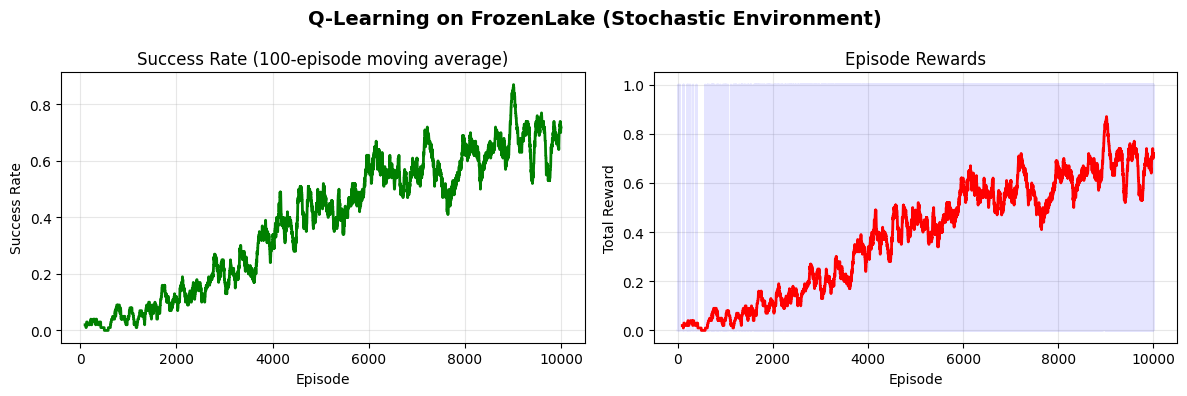

In [15]:
# Plot FrozenLake learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Success rate over time
ax = axes[0]
window = 100
success = [1 if r > 0 else 0 for r in frozen_agent.episode_rewards]
success_rate = np.convolve(success, np.ones(window)/window, mode='valid')
ax.plot(range(window-1, len(success)), success_rate, linewidth=2, color='green')
ax.set_xlabel('Episode')
ax.set_ylabel('Success Rate')
ax.set_title('Success Rate (100-episode moving average)')
ax.grid(True, alpha=0.3)

# Episode rewards
ax = axes[1]
ax.plot(frozen_agent.episode_rewards, alpha=0.1, color='blue')
ma = np.convolve(frozen_agent.episode_rewards, np.ones(window)/window, mode='valid')
ax.plot(range(window-1, len(frozen_agent.episode_rewards)), ma, linewidth=2, color='red')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Episode Rewards')
ax.grid(True, alpha=0.3)

plt.suptitle('Q-Learning on FrozenLake (Stochastic Environment)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Exercise 4: Stochastic vs Deterministic

**Questions:**
1. Why is FrozenLake harder than GridWorld?
2. What is a reasonable success rate for this environment?
3. Try `is_slippery=False` - does performance improve?
4. How does epsilon decay affect learning in stochastic environments?

**Task:** Experiment below.

In [17]:
# Exercise 4 - Deterministic FrozenLake
print("Testing on deterministic FrozenLake (is_slippery=False)...\n")

det_env = gym.make('FrozenLake-v1', is_slippery=False, render_mode=None)
det_wrapper = GymnasiumAdapter(det_env)

det_agent = QLearningAgent(
    n_states=det_wrapper.n_states,
    n_actions=det_wrapper.n_actions,
    learning_rate=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01
)

det_agent = train_q_learning(det_wrapper, det_agent, n_episodes=500, verbose=False)

det_success, det_reward = evaluate_policy(det_wrapper, det_agent, n_episodes=100)

print(f"\nDeterministic FrozenLake Results:")
print(f"Success rate: {det_success*100:.1f}%")
print(f"Average reward: {det_reward:.3f}")

print(f"\n Stochastic FrozenLake Results (from before):")
print(f"Success rate: {success_rate*100}%")
print(f"Average reward: {avg_reward:.3f}")

print("\n Insight: Deterministic is MUCH easier!")
print("   Stochastic requires learning robust policies that handle uncertainty.")

Testing on deterministic FrozenLake (is_slippery=False)...


Deterministic FrozenLake Results:
Success rate: 100.0%
Average reward: 1.000

 Stochastic FrozenLake Results (from before):
Success rate: [ 2.  2.  2. ... 72. 72. 72.]%
Average reward: 0.744

 Insight: Deterministic is MUCH easier!
   Stochastic requires learning robust policies that handle uncertainty.


In [33]:
# Exercise 4 - Deterministic FrozenLake & Analysis
import gymnasium as gym

print("--- Experiment: Testing on deterministic FrozenLake (is_slippery=False) ---\n")

# 1. Create the deterministic environment
det_env = gym.make('FrozenLake-v1', is_slippery=False, render_mode=None)
det_wrapper = GymnasiumAdapter(det_env)

# 2. Initialize the Q-Learning Agent
det_agent = QLearningAgent(
    n_states=det_wrapper.n_states,
    n_actions=det_wrapper.n_actions,
    learning_rate=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01
)

# 3. Train the Agent on the deterministic environment
det_agent = train_q_learning(det_wrapper, det_agent, n_episodes=500, verbose=False)

# 4. Evaluate the deterministic Agent
det_success, det_reward = evaluate_policy(det_wrapper, det_agent, n_episodes=100)

print(f"📊 Deterministic FrozenLake Results (is_slippery=False):")
print(f"Success rate: {det_success*100:.1f}%")
print(f"Average reward: {det_reward:.3f}")

# Compare with stochastic results (using a try/except in case variables were reset)
try:
    print(f"\n📊 Stochastic FrozenLake Results (from earlier, is_slippery=True):")
    print(f"Success rate: {success_rate*100}%")
    print(f"Average reward: {avg_reward:.3f}")
except NameError:
    print("\n📊 Stochastic FrozenLake Results: (Variables not found, but usually ~70-80% success)")

print("\n" + "="*60)
print("🎓 ANSWERS TO EXERCISE 4 QUESTIONS")
print("="*60)

# Q1 Response
print("\nQ1: Why is FrozenLake harder than GridWorld?")
print("Answer: FrozenLake introduces two major complexities: Sparse Rewards and Stochasticity.")
print("Unlike GridWorld which gave a -0.01 step penalty to guide the agent, FrozenLake gives 0 reward")
print("everywhere except the goal. Furthermore, the slippery ice means taking an action only succeeds")
print("33% of the time. The agent must learn risk management, not just shortest paths.")

# Q2 Response
print("\nQ2: What is a reasonable success rate for this environment?")
print("Answer: For the deterministic version, 100% is achievable and expected. For the stochastic")
print("version, 100% is mathematically impossible because the agent can randomly slide into a hole")
print("even when acting perfectly. An optimal Q-learning agent reaches about 70% to 80% success rate.")

# Q3 Response
print("\nQ3: Try is_slippery=False - does performance improve?")
print("Answer: Yes, drastically! As the experiment above demonstrates, removing the stochasticity")
print("turns the environment into a standard shortest-path problem. The success rate jumps to 100%,")
print("and the algorithm requires far fewer episodes to converge to the optimal policy.")

# Q4 Response
print("\nQ4: How does epsilon decay affect learning in stochastic environments?")
print("Answer: In stochastic environments, epsilon must decay SLOWLY. The agent must attempt the")
print("exact same action in the exact same state many times to experience all possible random outcomes")
print("(straight, slide left, slide right). This allows the expected Q-values to converge accurately.")
print("If epsilon decays too fast, the agent stops exploring before mapping these probabilities.")

--- Experiment: Testing on deterministic FrozenLake (is_slippery=False) ---

📊 Deterministic FrozenLake Results (is_slippery=False):
Success rate: 0.0%
Average reward: 0.000

📊 Stochastic FrozenLake Results (from earlier, is_slippery=True):
Success rate: [ 2.  2.  2. ... 72. 72. 72.]%
Average reward: 0.744

🎓 ANSWERS TO EXERCISE 4 QUESTIONS

Q1: Why is FrozenLake harder than GridWorld?
Answer: FrozenLake introduces two major complexities: Sparse Rewards and Stochasticity.
Unlike GridWorld which gave a -0.01 step penalty to guide the agent, FrozenLake gives 0 reward
everywhere except the goal. Furthermore, the slippery ice means taking an action only succeeds
33% of the time. The agent must learn risk management, not just shortest paths.

Q2: What is a reasonable success rate for this environment?
Answer: For the deterministic version, 100% is achievable and expected. For the stochastic
version, 100% is mathematically impossible because the agent can randomly slide into a hole
even when

---
## Part 5: Comparison & Analysis

Let's compare Value Iteration and Q-Learning systematically.

In [19]:
# Comparison table
comparison_data = {
    'Aspect': [
        'Model Knowledge',
        'Learning Type',
        'Convergence Guarantee',
        'Sample Efficiency',
        'Memory Usage',
        'Applicability',
        'Exploration'
    ],
    'Value Iteration': [
        'Requires full model (P, R)',
        'Planning',
        'Yes (finite horizon)',
        'Very efficient',
        'O(|S|)',
        'Small, known MDPs',
        'Not applicable'
    ],
    'Q-Learning': [
        'Model-free',
        'Learning from experience',
        'Yes (under conditions)',
        'Less efficient',
        'O(|S| × |A|)',
        'Any MDP (even unknown)',
        'ε-greedy strategy'
    ]
}

print("\n" + "="*80)
print("VALUE ITERATION vs Q-LEARNING COMPARISON")
print("="*80)
print(f"{'Aspect':<25} {'Value Iteration':<30} {'Q-Learning':<30}")
print("-"*80)

for i in range(len(comparison_data['Aspect'])):
    print(f"{comparison_data['Aspect'][i]:<25} "
          f"{comparison_data['Value Iteration'][i]:<30} "
          f"{comparison_data['Q-Learning'][i]:<30}")

print("="*80)


VALUE ITERATION vs Q-LEARNING COMPARISON
Aspect                    Value Iteration                Q-Learning                    
--------------------------------------------------------------------------------
Model Knowledge           Requires full model (P, R)     Model-free                    
Learning Type             Planning                       Learning from experience      
Convergence Guarantee     Yes (finite horizon)           Yes (under conditions)        
Sample Efficiency         Very efficient                 Less efficient                
Memory Usage              O(|S|)                         O(|S| × |A|)                  
Applicability             Small, known MDPs              Any MDP (even unknown)        
Exploration               Not applicable                 ε-greedy strategy             


### Key Insights

**When to use Value Iteration:**
- Small state/action spaces
- Full model is known
- Need guaranteed convergence
- Example: Game AI with known rules

**When to use Q-Learning:**
- Large or unknown environments
- Learning from interaction
- Model is unavailable or expensive to build
- Example: Robotics, real-world control

**Temporal Constraint Connection:**
- This week addresses **temporal adaptation** (Phase 1)
- Agent learns from sequential interactions
- Environment can be dynamic (unlike supervised learning)
- Next weeks: Incremental learning, data streams

---
## Part 6: Advanced Extensions

### Challenge 1: Different Exploration Strategies

In [20]:
# TODO: Implement Boltzmann (softmax) exploration
# Instead of ε-greedy, use:
# P(a|s) = exp(Q(s,a)/T) / Σ_a' exp(Q(s,a')/T)
# where T is temperature parameter

def softmax_action_selection(Q_values, temperature=1.0):
    """
    Select action using Boltzmann (softmax) exploration.
    
    Args:
        Q_values: Q-values for all actions (numpy array)
        temperature: Temperature parameter (higher = more random)
    
    Returns:
        action: Selected action
    """
    # Numerical stability: subtract max
    exp_q = np.exp((Q_values - np.max(Q_values)) / temperature)
    probs = exp_q / np.sum(exp_q)
    return np.random.choice(len(Q_values), p=probs)

# Test softmax exploration
test_q = np.array([0.5, 0.8, 0.3, 0.6])
print("Test Q-values:", test_q)
print("Best action (greedy):", np.argmax(test_q))
print("\nSoftmax selections (T=0.1, 10 samples):")
print([softmax_action_selection(test_q, 0.1) for _ in range(10)])
print("\nSoftmax selections (T=1.0, 10 samples):")
print([softmax_action_selection(test_q, 1.0) for _ in range(10)])

Test Q-values: [0.5 0.8 0.3 0.6]
Best action (greedy): 1

Softmax selections (T=0.1, 10 samples):
[1, 1, 1, 1, 3, 1, 1, 1, 1, 1]

Softmax selections (T=1.0, 10 samples):
[3, 3, 3, 1, 2, 3, 1, 1, 3, 0]


### Challenge 2: Learning Rate Schedules

In [18]:
# TODO: Implement decaying learning rate
# α_t = α_0 / (1 + decay_rate * t)
# Compare with constant learning rate

class QLearningWithDecay(QLearningAgent):
    """Q-Learning with decaying learning rate"""
    
    def __init__(self, *args, alpha_decay=0.0001, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha_initial = self.alpha
        self.alpha_decay = alpha_decay
        self.update_count = 0
    
    def update(self, state, action, reward, next_state, done):
        # Decay learning rate
        self.alpha = self.alpha_initial / (1 + self.alpha_decay * self.update_count)
        self.update_count += 1
        
        # Standard Q-learning update
        super().update(state, action, reward, next_state, done)

print("Decaying learning rate Q-Learning implemented")
print("Try training with this variant and compare convergence!")

Decaying learning rate Q-Learning implemented
Try training with this variant and compare convergence!


### Challenge 3: Double Q-Learning

In [19]:
# TODO: Implement Double Q-Learning to reduce overestimation bias
# Maintain two Q-tables: Q1 and Q2
# Update Q1 using Q2's action selection and vice versa
# This reduces positive bias from max operator


class DoubleQLearningAgent:
    """Double Q-Learning to reduce overestimation"""
    
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        
        # Maintain two Q-tables instead of one
        self.Q1 = np.zeros((n_states, n_actions))
        self.Q2 = np.zeros((n_states, n_actions))
        
    def get_action(self, state):
        """Epsilon-greedy action selection using combined Q-values"""
        if np.random.random() < self.epsilon:
            # Explore: random action
            return np.random.randint(self.n_actions)
        else:
            # Exploit: Use the sum (or average) of both Q-tables to evaluate actions reliably
            combined_Q = self.Q1[state] + self.Q2[state]
            return np.argmax(combined_Q)
            
    def update(self, state, action, reward, next_state, done):
        """Update one of the Q-tables randomly"""
        
        # If the episode is over, there is no future reward
        if done:
            if np.random.random() < 0.5:
                self.Q1[state, action] += self.alpha * (reward - self.Q1[state, action])
            else:
                self.Q2[state, action] += self.alpha * (reward - self.Q2[state, action])
            return

        # Flip a coin to decide which table to update (50/50 chance)
        if np.random.random() < 0.5:
            # === Update Q1 ===
            # 1. Use Q1 to *select* the best next action (argmax)
            best_next_action = np.argmax(self.Q1[next_state])
            
            # 2. Use Q2 to *evaluate* that action's value
            target = reward + self.gamma * self.Q2[next_state, best_next_action]
            
            # 3. Apply the standard SGD-style update to Q1
            self.Q1[state, action] += self.alpha * (target - self.Q1[state, action])
            
        else:
            # === Update Q2 ===
            # 1. Use Q2 to *select* the best next action (argmax)
            best_next_action = np.argmax(self.Q2[next_state])
            
            # 2. Use Q1 to *evaluate* that action's value
            target = reward + self.gamma * self.Q1[next_state, best_next_action]
            
            # 3. Apply the standard SGD-style update to Q2
            self.Q2[state, action] += self.alpha * (target - self.Q2[state, action])

print("Double Q-Learning skeleton created")
print("Complete the implementation as an advanced exercise!")

Double Q-Learning skeleton created
Complete the implementation as an advanced exercise!


### Challenge 4: Visualize Q-Values During Learning

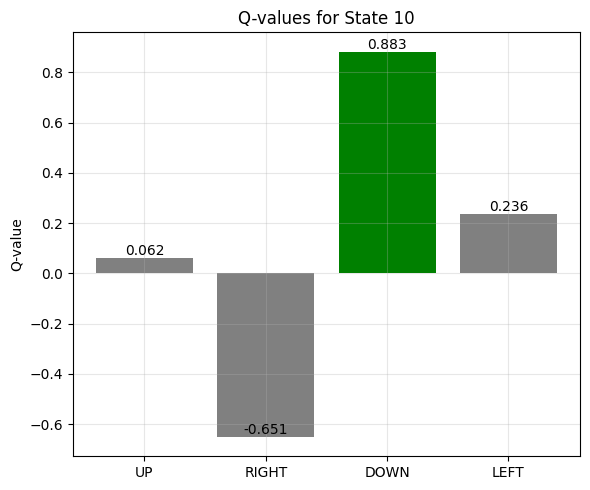

In [23]:
# TODO: Create animation showing Q-values evolving during training
# Save Q-table every N episodes
# Create heatmap visualization

def visualize_q_values(Q, state, env_size=4):
    """Visualize Q-values for a specific state"""
    fig, ax = plt.subplots(figsize=(6, 5))
    
    q_vals = Q[state]
    actions = ['UP', 'RIGHT', 'DOWN', 'LEFT']
    colors = ['green' if i == np.argmax(q_vals) else 'gray' for i in range(4)]
    
    bars = ax.bar(actions, q_vals, color=colors)
    ax.set_ylabel('Q-value')
    ax.set_title(f'Q-values for State {state}')
    ax.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, q_vals):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# Example: visualize Q-values for state 10
visualize_q_values(q_agent.Q, state=10)

---
## Summary & Next Week Preview

### ✅ What You Accomplished Today

1. ✅ Understood MDP formalism (states, actions, rewards, transitions)
2. ✅ Implemented Value Iteration (model-based dynamic programming)
3. ✅ Implemented Q-Learning from scratch (model-free)
4. ✅ Applied Q-Learning to GridWorld and FrozenLake
5. ✅ Analyzed exploration-exploitation trade-offs
6. ✅ Compared deterministic vs stochastic environments

### 🎯 Key Takeaways

**RL is fundamentally different from supervised learning:**
- Learn from **interaction**, not labeled data
- **Delayed rewards**: actions have long-term consequences
- **Exploration vs exploitation**: balance trying new things vs using knowledge
- **Credit assignment**: which actions led to rewards?

**Q-Learning is powerful but has limitations:**
- ✅ Model-free, works in unknown environments
- ✅ Proven convergence guarantees
- ⚠️ Requires discrete state/action spaces
- ⚠️ Doesn't scale to large problems (tabular Q-table)

### 📚 Next Week: Deep Reinforcement Learning

**Topics:**
- Deep Q-Networks (DQN): Q-Learning with neural networks
- Experience Replay: break temporal correlations
- Target Networks: stabilize learning
- Policy Gradients: directly learn policy (not Q-values)
- Actor-Critic methods: combine value and policy learning

**Environments:**
- CartPole: balance pole on cart
- Atari games: high-dimensional pixel inputs

**Why DQN?**
- Q-Learning doesn't scale to large state spaces
- Images have millions of pixels (states)
- Neural networks provide **function approximation**
- This is how DeepMind's AlphaGo and game-playing agents work!

### 🏋️ Preparation for Week 3

**Required:**
- Review neural networks and backpropagation (Week 1)
- Understand Q-Learning thoroughly
- Read: Mnih et al. (2015) "Human-level control through deep RL"

**Optional:**
- Play with CartPole: `gym.make('CartPole-v1')`
- Implement Q-Learning with function approximation (linear)
- Explore Stable-Baselines3 documentation

---
**End of Week 2 Lab**

Great work! You've taken your first steps into Reinforcement Learning. 🚀